In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pickle

# Set visualization style
sns.set_theme(style="whitegrid")

# Load your uploaded dataset
try:
    df = pd.read_csv('loan_approval_dataset.csv')
except FileNotFoundError:
    print("Please upload 'loan_approval_dataset.csv' to your Colab directory!")

print(f"Dataset Dimensions: {df.shape}")
df.head(5)

Dataset Dimensions: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
# 1. Strip whitespaces from column names
df.columns = df.columns.str.strip()

# 2. Strip whitespaces from text-based values
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

# 3. Drop the identifier column
df = df.drop(columns=['loan_id'])

# 4. Convert text categories into numerical data
le = LabelEncoder()
categorical_cols = ['education', 'self_employed', 'loan_status']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Data columns successfully cleaned and encoded!")
print("Columns list:", df.columns.tolist())

Data columns successfully cleaned and encoded!
Columns list: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [4]:
# Separate features (X) and target variable (y)
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set row count: {X_train.shape[0]}")
print(f"Testing set row count: {X_test.shape[0]}")

Training set row count: 3415
Testing set row count: 854


In [6]:
# 1. Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# 2. Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 3. Print Performance Results
print(" --- Decision Tree Performance ---")
print(f"Accuracy: {accuracy_score(y_test, dt_preds) * 100:.2f}%")
print(classification_report(y_test, dt_preds))

print("\n --- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds) * 100:.2f}%")
print(classification_report(y_test, rf_preds))

 --- Decision Tree Performance ---
Accuracy: 97.78%
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854


 --- Random Forest Performance ---
Accuracy: 97.78%
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



/tmp/ipykernel_976/1725089377.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette="magma", order=df.drop(columns=['loan_status']).columns[np.argsort(importances)[::-1]])


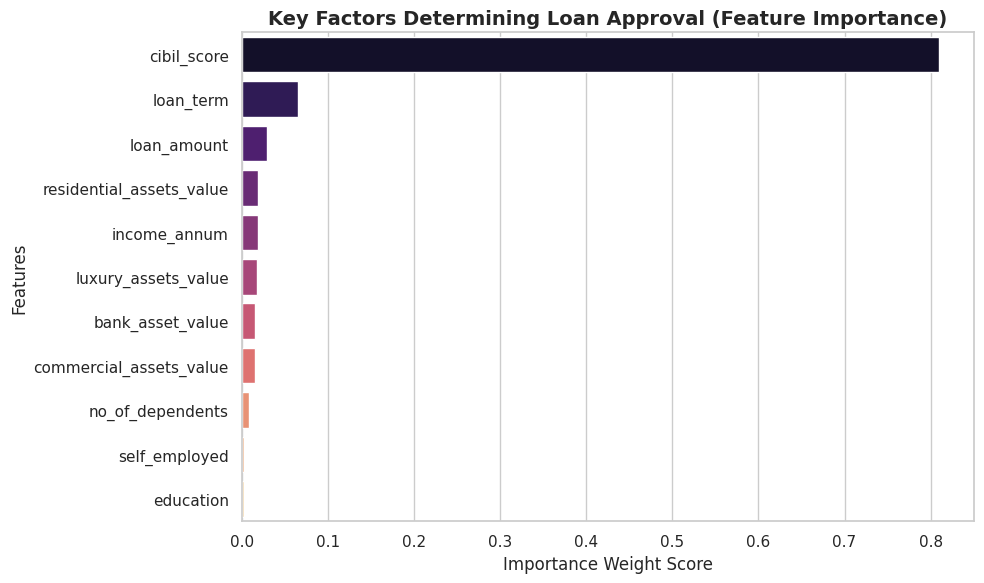

In [7]:
# Extract and plot feature importances from Random Forest
importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features, palette="magma", order=df.drop(columns=['loan_status']).columns[np.argsort(importances)[::-1]])
plt.title("Key Factors Determining Loan Approval (Feature Importance)", fontsize=14, fontweight='bold')
plt.xlabel("Importance Weight Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig('feature_importance.png') # Saves plot image safely
plt.show()

In [9]:
with open('loan_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

print(" Final Model weights successfully compiled and saved as 'loan_model.pkl'!")

 Final Model weights successfully compiled and saved as 'loan_model.pkl'!
